# LD50 Toxicity Prediction — Starter Notebook

**PharmaHacks 2026 ML Challenge**

---

**Your task:** Predict the acute toxicity (LD50) of drug-like molecules from their chemical structure.

**The target** (`Y`) is the log-transformed LD50 in mg/kg. Higher values = less toxic, lower values = more toxic. This is a **regression** problem.

Each molecule is given as a **SMILES string** — a text encoding of molecular structure (e.g. `CC(=O)Oc1ccccc1C(=O)O` is aspirin).

## The Dataset

We use the **LD50_Zhu** dataset from [Therapeutics Data Commons (TDC)](https://tdcommons.ai/single_pred_tasks/tox/#ld50-zhu), originally published in:

> Zhu et al., *Quantitative Structure-Activity Relationship Modeling of Rat Acute Toxicity by Oral Exposure*, Chemical Research in Toxicology (2009).

**LD50** (Lethal Dose, 50%) is the dose of a substance required to kill 50% of a test population (measured in rats, oral administration). It is one of the most fundamental measures of acute toxicity in pharmacology.

The dataset contains ~7,400 molecules. Each row has three columns:

- **Drug_ID**: a unique identifier
- **Drug**: the molecular structure as a [SMILES](https://en.wikipedia.org/wiki/Simplified_molecular-input_line-entry_system) string
- **Y**: the target: log-transformed LD50 in mg/kg (**higher = less toxic, lower = more toxic**)

**Task:** Regression: predict the continuous log(LD50) value from molecular structure.

In [1]:
# don't worry if this takes a while
# !pip install PyTDC rdkit xgboost -q
# IMPORTANT: If you are running this in google collab, after installing packages RESTART YOUR RUNTIME
# Then skip this cell and you can run the rest of the notebook (package are already installed)
# If you get ERROR: pip's dependency resolver does not currently take into account all the packages that are installed
# you can safely ignore it

In [2]:
# Local / Windows (Python 3.12+): PyTDC needs pkg_resources, which setuptools 82+ removed.
# Do NOT run: pip install pkg_resources  (not a package — use setuptools pin below.)
!python -m pip install --upgrade pip wheel
!python -m pip install "setuptools>=71,<82"

!pip install rdkit xgboost pandas numpy scikit-learn -q

!pip install PyTDC --no-deps

!pip install tqdm pandas numpy scikit-learn fuzzywuzzy huggingface_hub python-Levenshtein -q
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


## 2. Load the Data

In [3]:
from tdc.single_pred import Tox

data  = Tox(name='LD50_Zhu')
split = data.get_split()

train_df = split['train']
valid_df = split['valid']
test_df  = split['test']

print(f"Train: {len(train_df)}  |  Valid: {len(valid_df)}  |  Test: {len(test_df)}")
print(f"Columns: {list(train_df.columns)}")
train_df.head()

Found local copy...
Loading...
Done!


Train: 5170  |  Valid: 738  |  Test: 1477
Columns: ['Drug_ID', 'Drug', 'Y']


,Drug_ID,Drug,Y
0,"Methane, tribromo-",BrC(Br)Br,2.343
1,Bromoethene (9CI),C=CBr,2.330
2,"1,1'-Biphenyl, hexabromo-",Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465
3,"Isothiocyanic acid, p-bromophenyl ester",S=C=Nc1ccc(Br)cc1,2.729
4,"Benzene, bromo-",Brc1ccccc1,1.765


## 3. Where to Go From Here

Here's a suggested roadmap feel free to skip around or go in a completely different direction.

**Step 1: Explore the data.** Plot the distribution of the target variable. Look at summary statistics. Are there outliers? Is the distribution skewed?

**Step 2: Featurize the molecules.** SMILES strings are text and models need numbers. Convert each molecule to a numerical vector using RDKit.

You can also explore MACCS keys, physicochemical descriptors (molecular weight, logP, etc.), or atom-pair fingerprints.

**Step 3: Train a simple model.** Start with something basic like Ridge regression or Random Forest from scikit-learn. Evaluate on the validation set using R², MAE, and RMSE.

**Step 4: Improve.** Try more models (XGBoost, Gradient Boosting, etc.), tune hyperparameters, engineer better features, analyze your errors.



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import shap
import random
import os

def set_seed(seed=42):
    # Set all random seeds to guarantee reproducibility of results
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Random seed fixed at {seed}: Reproducibility guaranteed.")

set_seed(42)

# Aesthetic configuration for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


Random seed fixed at 42: Reproducibility guaranteed.


In [5]:
# CELL 3: Molecular Representation - Morgan

# Convert a SMILES string into a Morgan fingerprint (numpy binary vector)
def smiles_to_morgan(smiles, radius=2, n_bits=1024):

    # Convert the 'smiles' string into an RDKit Molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return np.zeros(n_bits, dtype=np.int8)

    # Generate the fingerprint
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = mfpgen.GetFingerprint(mol)

    # Convert 'fp' (an RDKit object) into a Numpy array (use DataStructs.ConvertToNumpyArray)
    arr = np.zeros(n_bits, dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr

# The goal is to create three new DataFrames (or Numpy matrices): X_train_morgan, X_valid_morgan, X_test_morgan
X_train_morgan = pd.DataFrame([smiles_to_morgan(s) for s in train_df['Drug']])
X_valid_morgan = pd.DataFrame([smiles_to_morgan(s) for s in valid_df['Drug']])
X_test_morgan  = pd.DataFrame([smiles_to_morgan(s) for s in test_df['Drug']])

print(f"Fingerprints generated without warnings! Shape: {X_train_morgan.shape}")

Fingerprints generated without warnings! Shape: (5170, 1024)


In [6]:
# CELL 5: Advanced Feature Engineering (Physicochemical & MACCS)

def get_advanced_descriptors(smiles):
    # Extract physicochemical properties and toxicophores (MACCS) from a molecule.
    mol = Chem.MolFromSmiles(smiles)
    
    # We have 10 physicochemical descriptors + 167 MACCS keys (key 0 is always empty in RDKit).
    if mol is None:
        return [0.0]*10 + [0]*167 
    
    # Extract the 10 physicochemical descriptors using the Descriptors module
    
    # Molecular weight (g/mol)
    mw = Descriptors.MolWt(mol)   
    
    # Predicted octanol-water partition coefficient (logP): lipophilicity measure
    logp = Descriptors.MolLogP(mol)   
    
    # Number of hydrogen-bond donors (e.g., -OH, -NH groups)
    hbd = Descriptors.NumHDonors(mol)   
    
    # Number of hydrogen-bond acceptors (e.g., O, N atoms with lone pairs)    
    hba = Descriptors.NumHAcceptors(mol)   
    
    # Topological Polar Surface Area: sum of polar surface contributions, correlates with permeability
    tpsa = Descriptors.TPSA(mol)   
    
    # Chemical reactivity (charges)
    AllChem.ComputeGasteigerCharges(mol)
    charge = max([float(mol.GetAtomWithIdx(i).GetProp('_GasteigerCharge')) for i in range(mol.GetNumAtoms())])

    # Flexibility (rotatable bonds)
    rot = Descriptors.NumRotatableBonds(mol)
    
    # Shape complexity (BertzCT)
    bertz = Descriptors.BertzCT(mol)
    
    # Number of aromatic rings (strong link with toxicity)
    arom = Descriptors.NumAromaticRings(mol)
    
    # Carbon richness (FractionCSP3) - indicates whether the molecule is "flat" or 3D
    fsp3 = Descriptors.FractionCSP3(mol)

    physchem_features = [mw, logp, hbd, hba, tpsa, charge, rot, bertz, arom, fsp3]
    
    # Generate MACCS keys
    maccs_fp = MACCSkeys.GenMACCSKeys(mol)
    
    maccs_arr = np.zeros(167, dtype=np.int8)
    DataStructs.ConvertToNumpyArray(maccs_fp, maccs_arr)
    
    # Return one large list containing the 10 physicochemical values + the 167 zeros/ones
    return physchem_features + list(maccs_arr)

# Column names for the DataFrame
cols = ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA', 'Charge', 'RotBonds', 'Bertz', 'AromRings', 'fSP3'] + [f'MACCS_{i}' for i in range(167)]

X_train_adv = pd.DataFrame([get_advanced_descriptors(s) for s in train_df['Drug']], columns=cols)
X_valid_adv = pd.DataFrame([get_advanced_descriptors(s) for s in valid_df['Drug']], columns=cols)
X_test_adv = pd.DataFrame([get_advanced_descriptors(s) for s in test_df['Drug']], columns=cols)

print(f"Advanced descriptors extracted! Shape: {X_train_adv.shape}")

Advanced descriptors extracted! Shape: (5170, 177)


In [7]:
# CELL 6: Merging and Normalization (StandardScaling)

# Merge Morgan and Advanced features horizontally for each split.
X_train = pd.concat([X_train_morgan, X_train_adv], axis=1)
X_valid = pd.concat([X_valid_morgan, X_valid_adv], axis=1)
X_test = pd.concat([X_test_morgan, X_test_adv], axis=1)

# The first 10 columns of the 'adv' section are our continuous descriptors.
cols_to_scale = ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA', 'Charge', 'RotBonds', 'Bertz', 'AromRings', 'fSP3']
scaler = StandardScaler()

# Fit mean/std ONLY on the training set
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Apply the transformation (without refitting) on valid and test
X_valid[cols_to_scale] = scaler.transform(X_valid[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Prepare targets (Y) as NumPy arrays for training
y_train = train_df['Y'].values
y_valid = valid_df['Y'].values
y_test = test_df['Y'].values

print(f"Data ready for AI! Final X_train shape: {X_train.shape}")

Data ready for AI! Final X_train shape: (5170, 1201)


[0]	validation_0-rmse:0.94709	validation_1-rmse:0.96847
[100]	validation_0-rmse:0.53242	validation_1-rmse:0.64206
[200]	validation_0-rmse:0.46742	validation_1-rmse:0.61665
[300]	validation_0-rmse:0.42488	validation_1-rmse:0.60224
[400]	validation_0-rmse:0.39017	validation_1-rmse:0.59472
[500]	validation_0-rmse:0.36294	validation_1-rmse:0.58900
[600]	validation_0-rmse:0.33742	validation_1-rmse:0.58518
[700]	validation_0-rmse:0.31509	validation_1-rmse:0.58126
[800]	validation_0-rmse:0.29455	validation_1-rmse:0.57945
[900]	validation_0-rmse:0.27680	validation_1-rmse:0.57706
[1000]	validation_0-rmse:0.25998	validation_1-rmse:0.57602
[1039]	validation_0-rmse:0.25360	validation_1-rmse:0.57626
Model trained!
Validation Performance:
R2   : 0.6534
MAE  : 0.4128
RMSE : 0.5759


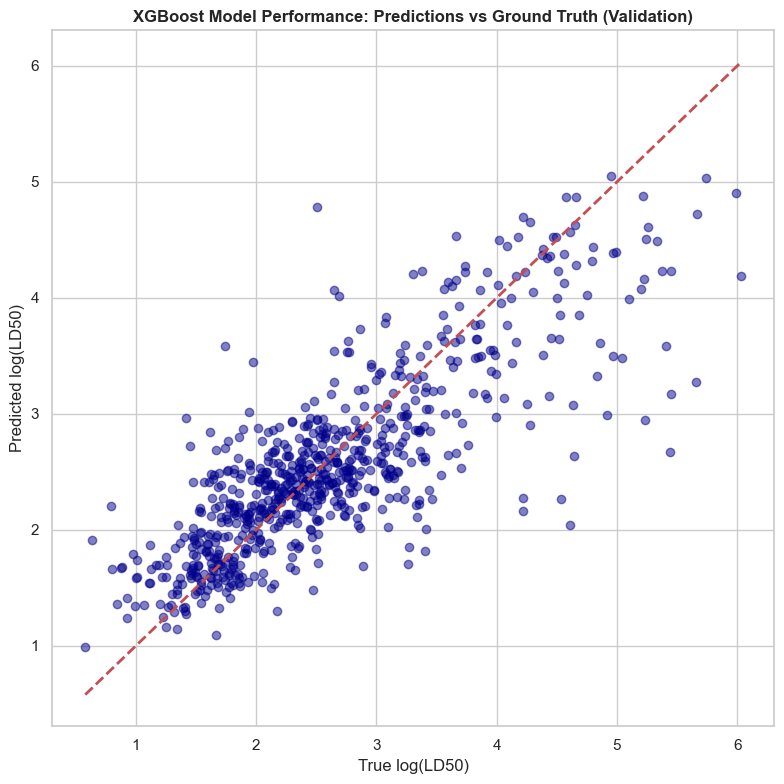

In [8]:
# CELL 7: Main Model Training (XGBoost)

# Instantiate the XGBRegressor model
# with aggressive hyperparameters to fight chemical noise
model_xgb_opt = xgb.XGBRegressor(
    n_estimators=1500,          # Number of trees
    learning_rate=0.03,         # Slower and more careful learning
    max_depth=7,                # Slightly deeper trees to capture complex interactions
    subsample=0.8,              # Uses 80% of rows per tree (reduces overfitting)
    colsample_bytree=0.4,       # Uses only 40% of columns per tree
    reg_alpha=1.0,              # L1 regularization (Lasso) to "switch off" fingerprint noise
    reg_lambda=2.0,             # L2 regularization (Ridge) to stabilize weights
    random_state=42,
    early_stopping_rounds=50    # Stops if no validation improvement after 50 trees
)

# Train the model on X_train and y_train
model_xgb_opt.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=100
)

print("Model trained!")

# Make predictions on the VALIDATION set (X_valid)
y_pred_valid_opt = model_xgb_opt.predict(X_valid)

# r2_score, mean_absolute_error, and mean_squared_error (with squared=False to get RMSE)
r2 = r2_score(y_valid, y_pred_valid_opt)
mae = mean_absolute_error(y_valid, y_pred_valid_opt)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred_valid_opt))

print(f"Validation Performance:")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_valid, y_pred_valid_opt, alpha=0.5, color='darkblue')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--', lw=2)
plt.title('XGBoost Model Performance: Predictions vs Ground Truth (Validation)', fontweight='bold')
plt.xlabel('True log(LD50)', fontsize=12)
plt.ylabel('Predicted log(LD50)', fontsize=12)
plt.tight_layout()
plt.show()

SHAP values computed! Generating summary chart...


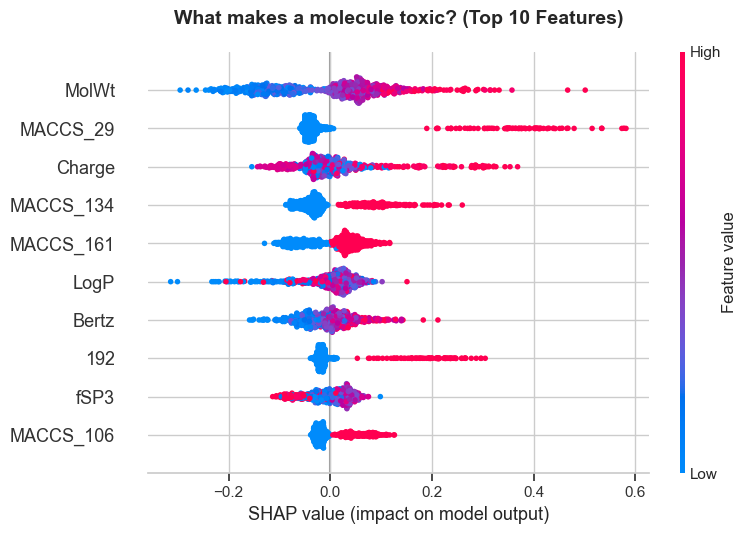

In [9]:
# CELL 8: Interpretability and Medical Explainability (SHAP)

# Initialize the SHAP explainer on our model
explainer = shap.TreeExplainer(model_xgb_opt)

# Compute SHAP values on the validation set
# We use X_valid to see how the model makes decisions on unseen data
shap_values = explainer(X_valid)

print("SHAP values computed! Generating summary chart...")

# The "Summary Plot"
plt.figure(figsize=(10, 8))
plt.title("What makes a molecule toxic? (Top 10 Features)", fontsize=14, fontweight='bold', pad=20)

# max_display=10 keeps the chart readable
shap.summary_plot(shap_values, X_valid, max_display=10, show=False) 

plt.tight_layout()
plt.show()

 Molecule under study: Ethanol, 2-((1-isobutyl-3,5-dimethylhexyl)oxy)- (index 42)
  True log(LD50) : 1.6330
  AI prediction  : 1.6678
  Absolute error : 0.0348


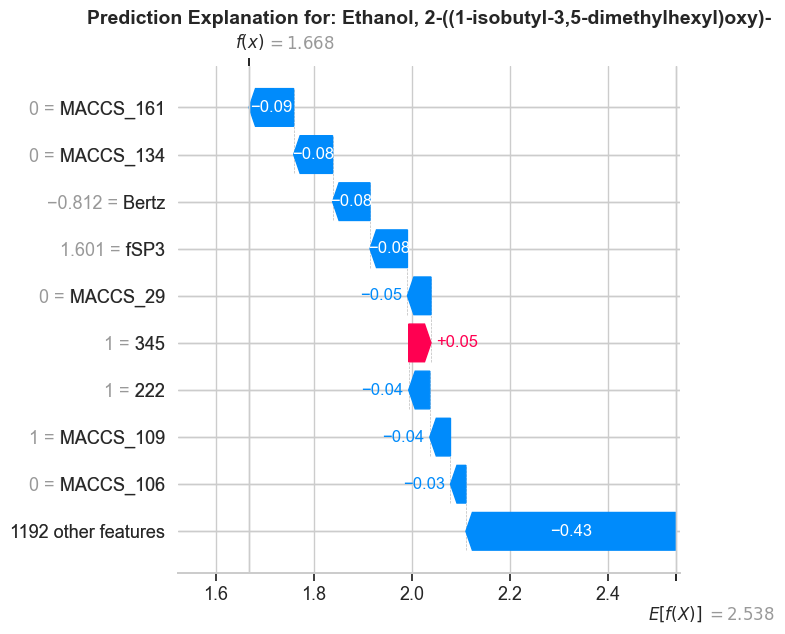

In [10]:
# CELL 9: Case Study (Individual Explainability with SHAP Waterfall)

# Specific molecule in the validation set
molecule_index = 42

molecule_id = valid_df['Drug_ID'].iloc[molecule_index]

# Retrieve the molecule, its true toxicity and its prediction
mol_data = X_valid.iloc[molecule_index]
true_y = y_valid[molecule_index]
pred_y = y_pred_valid_opt[molecule_index]

print(f" Molecule under study: {molecule_id} (index {molecule_index})")
print(f"  True log(LD50) : {true_y:.4f}")
print(f"  AI prediction  : {pred_y:.4f}")
print(f"  Absolute error : {abs(true_y - pred_y):.4f}")

# We need to extract the explanation for this one molecule only
shap_values_single = shap_values[molecule_index]

plt.figure(figsize=(10, 6))
plt.title(f"Prediction Explanation for: {molecule_id}", fontsize=14, fontweight='bold')

# The chart shows how each feature pushes the prediction
# upward (less toxic, red) or downward (more toxic, blue)
shap.plots.waterfall(shap_values_single, max_display=10, show=False)

plt.tight_layout()
plt.show()

In [11]:
# CELL 10: Final Evaluation on the Test Set

y_pred_test = model_xgb_opt.predict(X_test)

# Compute scores
r2_final = r2_score(y_test, y_pred_test)
mae_final = mean_absolute_error(y_test, y_pred_test)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("\n" + "="*50)
print("SCORES OFFICIELS FINAUX (TEST SET)")
print("="*50)
print(f"R2   : {r2_final:.4f}")
print(f"MAE  : {mae_final:.4f}")
print(f"RMSE : {rmse_final:.4f}")
print("="*50)

# Create the submission file (CSV)
submission_df = pd.DataFrame({
    'Drug_ID': test_df['Drug_ID'],
    'Drug_SMILES': test_df['Drug'],
    'True_logLD50': y_test,
    'Predicted_logLD50': y_pred_test
})

submission_filename = "LD50_Zhu_Predictions_Finales.csv"
submission_df.to_csv(submission_filename, index=False)


SCORES OFFICIELS FINAUX (TEST SET)
R2   : 0.6643
MAE  : 0.4021
RMSE : 0.5476
